In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 
warnings.filterwarnings('ignore')

data cleaning


In [2]:
import os

In [3]:
dataset_path = r"C:\Users\harsh\OneDrive\Desktop\dataset"

images = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".webp")):
            images.append([
                file,
                os.path.basename(root),
                os.path.join(root, file)
            ])

data = pd.DataFrame(images, columns=["filename", "class", "path"])

In [4]:
data

,filename,class,path
0,1.jpg,Accident,C:\Users\harsh\OneDrive\Desktop\dataset\Accide...
1,10.jpg,Accident,C:\Users\harsh\OneDrive\Desktop\dataset\Accide...
2,100.jpg,Accident,C:\Users\harsh\OneDrive\Desktop\dataset\Accide...
3,1000.jpg,Accident,C:\Users\harsh\OneDrive\Desktop\dataset\Accide...
4,1001.jpg,Accident,C:\Users\harsh\OneDrive\Desktop\dataset\Accide...
...,...,...,...
12906,Traffic_Roads 5 (95).jpg,traffic road,C:\Users\harsh\OneDrive\Desktop\dataset\road\R...
12907,Traffic_Roads 5 (96).jpg,traffic road,C:\Users\harsh\OneDrive\Desktop\dataset\road\R...
12908,Traffic_Roads 5 (97).jpg,traffic road,C:\Users\harsh\OneDrive\Desktop\dataset\road\R...
12909,Traffic_Roads 5 (98).jpg,traffic road,C:\Users\harsh\OneDrive\Desktop\dataset\road\R...


In [5]:
data.head()

,filename,class,path
0,1.jpg,Accident,C:\Users\harsh\OneDrive\Desktop\dataset\Accide...
1,10.jpg,Accident,C:\Users\harsh\OneDrive\Desktop\dataset\Accide...
2,100.jpg,Accident,C:\Users\harsh\OneDrive\Desktop\dataset\Accide...
3,1000.jpg,Accident,C:\Users\harsh\OneDrive\Desktop\dataset\Accide...
4,1001.jpg,Accident,C:\Users\harsh\OneDrive\Desktop\dataset\Accide...


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12911 entries, 0 to 12910
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  12911 non-null  object
 1   class     12911 non-null  object
 2   path      12911 non-null  object
dtypes: object(3)
memory usage: 302.7+ KB


In [7]:
data.describe()

,filename,class,path
count,12911,12911,12911
unique,11941,13,12911
top,9.jpg,Accident,C:\Users\harsh\OneDrive\Desktop\dataset\Accide...
freq,4,6191,1


In [8]:
data.isnull().sum()

filename    0
class       0
path        0
dtype: int64

corrupted image 


In [9]:
from PIL import Image

correcpt image
 

In [10]:
corrupted = []

for path in data["path"]:
    try:
        img = Image.open(path)
        img.verify()
    except:
        corrupted.append(path)

print("Corrupted images:", len(corrupted))

Corrupted images: 0


In [13]:
data["class"].value_counts()

class
Accident           6191
images             2641
fire_images         755
Potholes            480
blocked road        388
Clean road          370
normal              352
potholes            329
traffic road        300
Mask                290
Image               290
Smooth road         281
non_fire_images     244
Name: count, dtype: int64

<Axes: xlabel='class'>

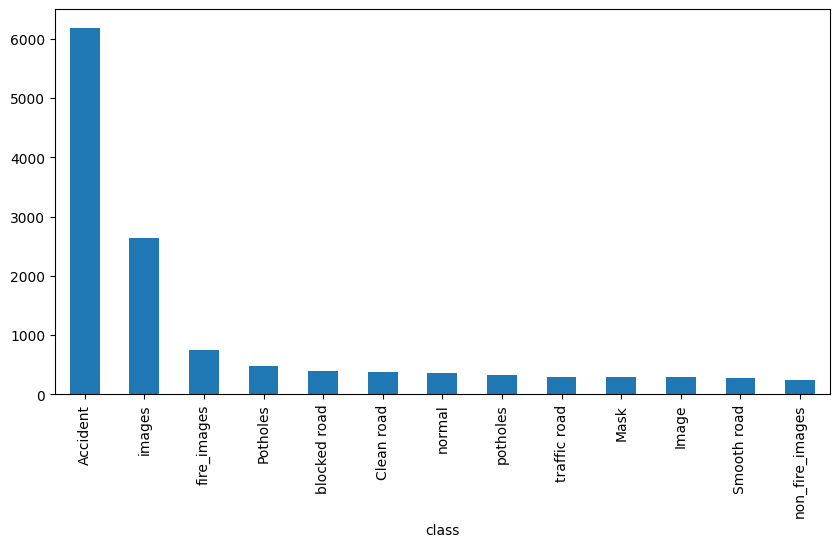

In [12]:
data["class"].value_counts().plot(kind="bar", figsize=(10, 5))

In [16]:
data["class"].unique()

array(['Accident', 'images', 'fire_images', 'non_fire_images', 'Image',
       'Mask', 'normal', 'potholes', 'blocked road', 'Clean road',
       'Potholes', 'Smooth road', 'traffic road'], dtype=object)

In [ ]:
classes = data["class"].unique()

image visual

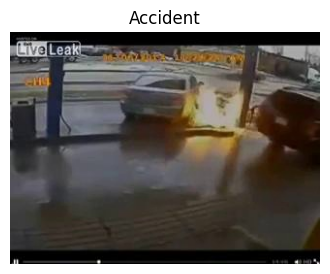

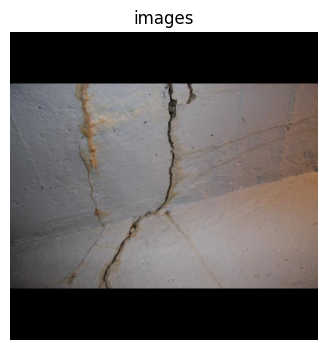

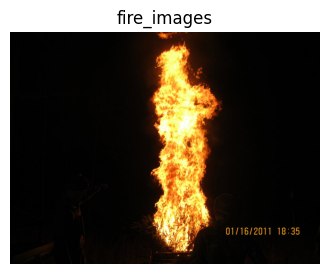

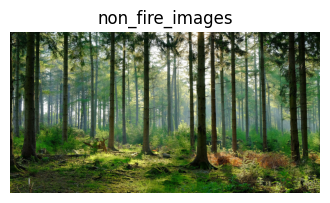

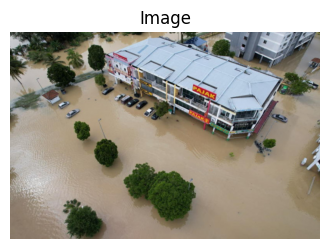

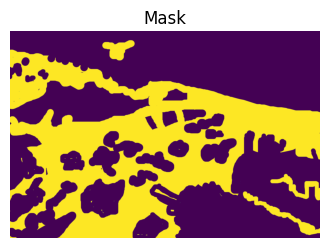

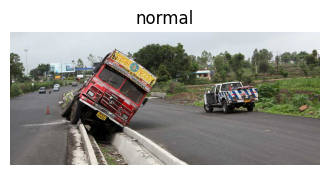

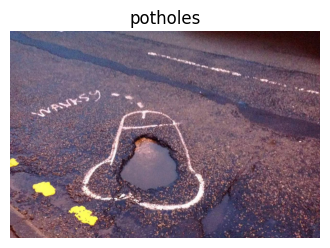

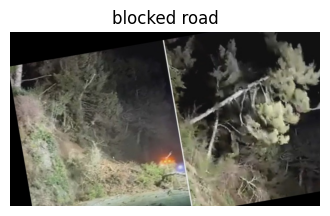

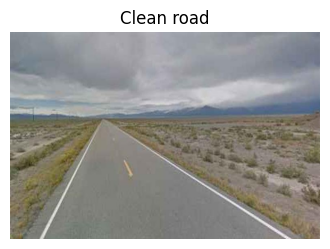

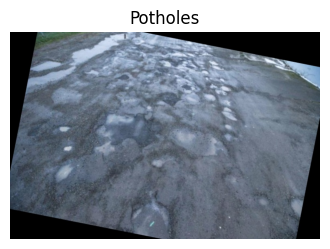

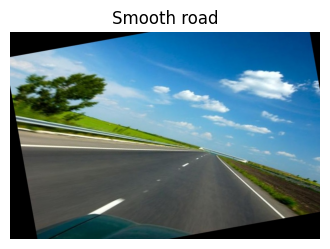

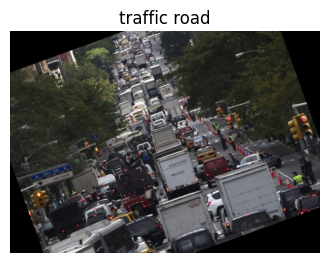

In [17]:
for cls in classes:
    class_data = data[data["class"] == cls]
    sample = class_data.sample(1).iloc[0]

    img = Image.open(sample["path"])

    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")
    plt.show()

In [18]:
data["path"].apply(lambda x: Image.open(x).size).value_counts().head(10)

path
(320, 240)     6191
(640, 640)     2642
(765, 512)     1091
(765, 510)      148
(765, 430)       94
(765, 574)       58
(1280, 720)      47
(512, 765)       43
(1200, 800)      40
(600, 338)       30
Name: count, dtype: int64

In [20]:
data["width"] = data["size"].apply(lambda x:x[0])
data["height"] = data["size"].apply(lambda x:x[1])

data[["width" , "height"]].describe()

,width,height
count,12911.000000,12911.000000
mean,584.999845,443.937418
std,472.519301,325.127702
min,160.000000,120.000000
25%,320.000000,240.000000
50%,500.000000,330.000000
75%,700.000000,640.000000
max,6720.000000,4608.000000


In [21]:
data[(data["width"] < 100) | (data["height"] < 100)]

,filename,class,path,size,width,height


In [22]:
data[data["width"] > 2000][["filename", "class", "width", "height"]]

,filename,class,width,height
8839,fire.105.png,fire_images,2048,1365
8872,fire.135.png,fire_images,2400,1600
8874,fire.137.png,fire_images,3500,2065
8875,fire.138.png,fire_images,3000,1977
8949,fire.204.png,fire_images,3500,2227
...,...,...,...,...
10992,305.jpg,potholes,2400,1456
11014,325.jpg,potholes,3200,1680
11025,39.jpg,potholes,4608,3072
11060,70.jpg,potholes,4032,3024


check imbalancing 


In [23]:
data["class"].value_counts().describe()

count      13.000000
mean      993.153846
std      1688.131701
min       244.000000
25%       290.000000
50%       352.000000
75%       480.000000
max      6191.000000
Name: count, dtype: float64

In [24]:
(data["class"].value_counts(normalize=True) * 100).round(2)

class
Accident           47.95
images             20.46
fire_images         5.85
Potholes            3.72
blocked road        3.01
Clean road          2.87
normal              2.73
potholes            2.55
traffic road        2.32
Mask                2.25
Image               2.25
Smooth road         2.18
non_fire_images     1.89
Name: proportion, dtype: float64

70% → Train
15% → Validation
15% → Test

In [25]:
from sklearn.model_selection import train_test_split

In [26]:
train_data, test_data = train_test_split(data, test_size=0.2, stratify=data["class"], random_state=42)

In [27]:
val_data, test_data = train_test_split(test_data, test_size=0.5, stratify=test_data["class"], random_state=42)

In [33]:
print("TRAIN:" , len(train_data))
print(train_data["class"].value_counts())
print("\nTrain %")
print((train_data["class"].value_counts(normalize=True) * 100).round(2))

print("\nVALIDATION:" , len(val_data))
print(val_data["class"].value_counts())
print("\nvalidation %")
print((val_data["class"].value_counts(normalize=True) * 100).round(2))

print("\nTEST:" , len(test_data))
print(test_data["class"].value_counts())
print("test %")
print((test_data["class"].value_counts(normalize=True) * 100).round(2))

TRAIN: 10328
class
Accident           4952
images             2113
fire_images         604
Potholes            384
blocked road        310
Clean road          296
normal              282
potholes            263
traffic road        240
Mask                232
Image               232
Smooth road         225
non_fire_images     195
Name: count, dtype: int64

Train %
class
Accident           47.95
images             20.46
fire_images         5.85
Potholes            3.72
blocked road        3.00
Clean road          2.87
normal              2.73
potholes            2.55
traffic road        2.32
Mask                2.25
Image               2.25
Smooth road         2.18
non_fire_images     1.89
Name: proportion, dtype: float64

VALIDATION: 1291
class
Accident           619
images             264
fire_images         75
Potholes            48
blocked road        39
Clean road          37
normal              35
potholes            33
traffic road        30
Image               29
Mask            

In [34]:
print("Total:", len(data))
print("Train:", len(train_data))
print("Validation:", len(val_data))
print("Test:", len(test_data))

Total: 12911
Train: 10328
Validation: 1291
Test: 1292


image prepossesing

In [35]:
img = Image.open(train_data.iloc[0]["path"]).convert("RGB")

img = img.resize((224, 224))

img_array = np.array(img) / 255.0

In [36]:
print("Image shape:", img_array.shape)
print("Minimum pixel value:", img_array.min())
print("Maximum pixel value:" , img_array.max())

Image shape: (224, 224, 3)
Minimum pixel value: 0.0
Maximum pixel value: 1.0


labelencoding


In [37]:
from sklearn.preprocessing import LabelEncoder

In [38]:
label_encoder = LabelEncoder()

train_data["label"] = label_encoder.fit_transform(train_data["class"])
val_data["label"] = label_encoder.transform(val_data["class"])
test_data["label"] = label_encoder.transform(test_data["class"])